Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


C:\Users\USer\AppData\Local\Temp\ipykernel_21380\1962104081.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns
C:\Users\USer\AppData\Local\Temp\ipykernel_21380\1962104081.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_fraud', data=df, palette='Set2')


Kolom yang berisi data teks/kategori: ['merchant_category']
Sisa fitur setelah kolom teks dihapus:
transaction_id           int64
amount                 float64
transaction_hour         int64
foreign_transaction      int64
location_mismatch        int64
device_trust_score       int64
velocity_last_24h        int64
cardholder_age           int64
is_fraud                 int64
dtype: object
Jumlah baris data: 10000
Jumlah kolom/fitur: 9

--- Informasi Struktur Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   foreign_transaction  10000 non-null  int64  
 4   location_mismatch    10000 non-null  int64  
 5   device_trust_score   10000 non-null  int64  
 6   velocity_last_24h    100

C:\Users\USer\AppData\Local\Temp\ipykernel_21380\1962104081.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_fraud', data=df, palette='Set2')


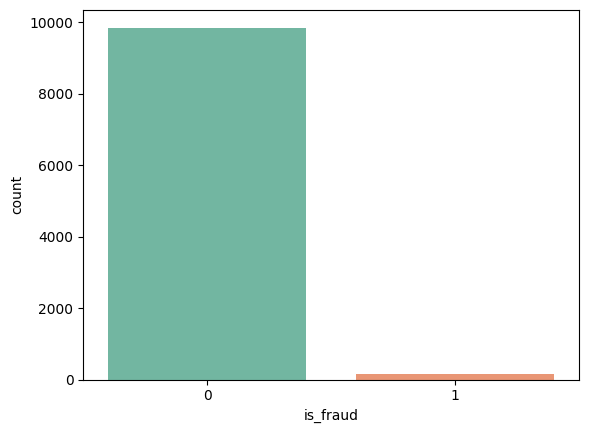

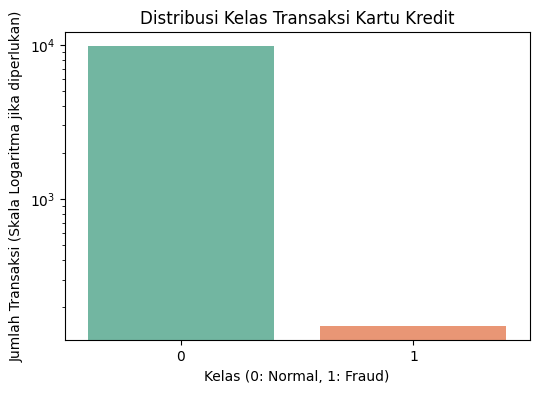

Jumlah baris data duplikat: 0
--- Data Setelah Proses Scaling ---
   scaled_amount  scaled_time
0      -0.521597     1.503345
1       2.086108    -1.241383
2       0.348151     0.781048
3      -0.066254    -1.096923
4      -0.829151     0.492130
--- Verifikasi Hasil Splitting ---
Dimensi X_train: (8000, 8) | Dimensi y_train: (8000,)
Dimensi X_test : (2000, 8)  | Dimensi y_test : (2000,)

Rasio Fraud di y_train: 1.512%
Rasio Fraud di y_test : 1.500%


In [1]:
# ==========================================
# BIODATA ANGGOTA KELOMPOK
# 1. MOKHAMAD HARIES EKO SANTOSO  (25051905002)
# 2. ISNAN BUROCHIM               (25051905007)
# ==========================================
%pip install pandas numpy matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Peringatan: Pastikan jalur file sesuai dengan struktur folder proyek
df = pd.read_csv('../dataset/creditcard.csv')

# Cek kolom mana saja yang bertipe objek/teks (Categorical Features)
categorical_cols = df.select_dtypes(include=['object']).columns
print("Kolom yang berisi data teks/kategori:", list(categorical_cols))

# Hapus semua kolom yang bertipe data teks/object
df = df.drop(columns=categorical_cols)

# Pastikan ulang kolom sudah bersih dari teks
print("Sisa fitur setelah kolom teks dihapus:")
print(df.dtypes)

# Menampilkan 5 data pertama untuk verifikasi awal
df.head()

# A. Memeriksa dimensi dataset
print(f"Jumlah baris data: {df.shape[0]}")
print(f"Jumlah kolom/fitur: {df.shape[1]}")

# B. Memeriksa tipe data dan nilai hilang (Missing Values)
print("\n--- Informasi Struktur Dataset ---")
print(df.info())

# C. Memeriksa apakah ada nilai kosong secara eksplisit
missing_values = df.isnull().sum().sum()
print(f"\nTotal missing values di dalam dataset: {missing_values}")

# A. Menghitung jumlah riil dan persentase distribusi kelas
class_counts = df['is_fraud'].value_counts()
class_percentage = df['is_fraud'].value_counts(normalize=True) * 100

# ...

sns.countplot(x='is_fraud', data=df, palette='Set2')

# ...

X = df.drop('is_fraud', axis=1)
y = df['is_fraud']
class_percentage = df['is_fraud'].value_counts(normalize=True) * 100

print("--- Distribusi Kelas Transaksi ---")
for cls, count in class_counts.items():
    label = "Normal (Legitimate)" if cls == 0 else "Fraudulent (Curang)"
    print(f"Kelas {cls} [{label}]: {count} transaksi ({class_percentage[cls]:.3f}%)")

# B. Visualisasi Distribusi Kelas menggunakan Bar Plot
plt.figure(figsize=(6, 4))
sns.countplot(x='is_fraud', data=df, palette='Set2')
plt.title('Distribusi Kelas Transaksi Kartu Kredit')
plt.xlabel('Kelas (0: Normal, 1: Fraud)')
plt.ylabel('Jumlah Transaksi (Skala Logaritma jika diperlukan)')
plt.yscale('log') # Menggunakan skala log agar kelas 1 yang sangat kecil tetap terlihat di grafik
plt.show()

# A. Cek jumlah data duplikat
duplicate_count = df.duplicated().sum()
print(f"Jumlah baris data duplikat: {duplicate_count}")

# B. Penghapusan data duplikat jika ditemukan
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"Data duplikat berhasil dihapus. Dimensi dataset baru: {df.shape}")

scaler = StandardScaler()

# Mengubah skala kolom 'Amount' dan 'Time'
df['scaled_amount'] = scaler.fit_transform(df['amount'].values.reshape(-1, 1))
df['scaled_time'] = scaler.fit_transform(df['transaction_hour'].values.reshape(-1, 1))

# Menghapus kolom asli 'Time' dan 'Amount' yang belum terskala agar tidak membingungkan model
df.drop(['transaction_hour', 'amount'], axis=1, inplace=True)

print("--- Data Setelah Proses Scaling ---")
print(df[['scaled_amount', 'scaled_time']].head())

# A. Memisahkan Fitur (X) dan Target (y)
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']


# Lakukan split ulang dengan data yang sudah bersih
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# B. Split Data dengan Proporsi 80:20 secara Stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y # CRITICAL: Menjaga rasio target tetap sama di train dan test set
)

print("--- Verifikasi Hasil Splitting ---")
print(f"Dimensi X_train: {X_train.shape} | Dimensi y_train: {y_train.shape}")
print(f"Dimensi X_test : {X_test.shape}  | Dimensi y_test : {y_test.shape}")
print(f"\nRasio Fraud di y_train: {y_train.value_counts(normalize=True)[1]*100:.3f}%")
print(f"Rasio Fraud di y_test : {y_test.value_counts(normalize=True)[1]*100:.3f}%")



Memulai pelatihan model Random Forest... (Mohon tunggu beberapa menit)
Pelatihan Random Forest Selesai.

--- Klasifikasi Report: Random Forest ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      1970
       Fraud       1.00      0.83      0.91        30

    accuracy                           1.00      2000
   macro avg       1.00      0.92      0.95      2000
weighted avg       1.00      1.00      1.00      2000

ROC-AUC Score Random Forest: 1.0000

--- Matriks Konfusi: Random Forest ---


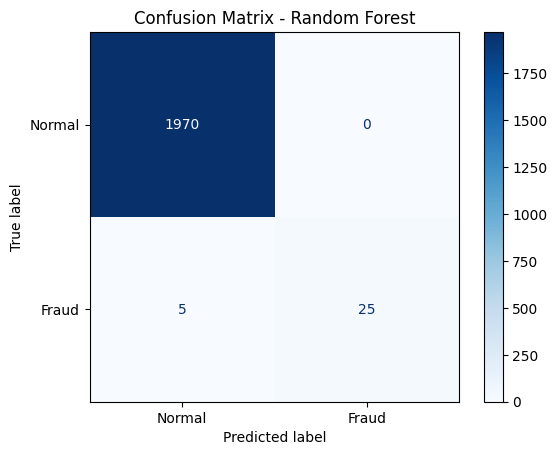

Rasio Kontaminasi yang Digunakan: 0.01512

Memulai pelatihan model Isolation Forest...
Pelatihan Isolation Forest Selesai.

--- Klasifikasi Report: Isolation Forest ---
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.99      1970
       Fraud       0.25      0.33      0.29        30

    accuracy                           0.97      2000
   macro avg       0.62      0.66      0.64      2000
weighted avg       0.98      0.97      0.98      2000


--- Matriks Konfusi: Isolation Forest ---


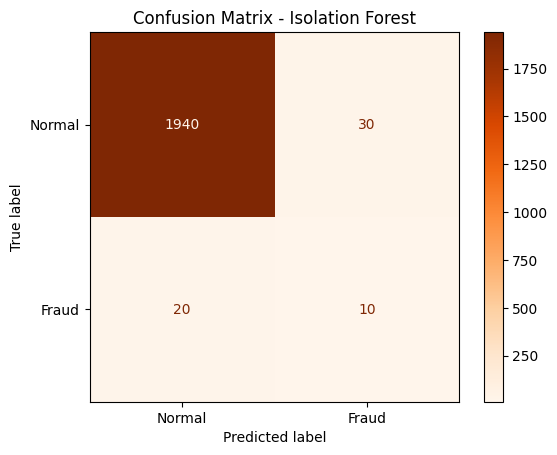

Lokasi penyimpanan absolut yang ditargetkan:
-> RF Classifier: c:\Users\USer\Documents\UAS_DataMining_Haries Eko-Isnan\model\rf_model.pkl

Sukses! Silakan cek folder 'model' Anda sekarang, file pasti sudah muncul.


In [2]:
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import pickle

# A. Inisialisasi dan Pelatihan Model
print("Memulai pelatihan model Random Forest... (Mohon tunggu beberapa menit)")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Pelatihan Random Forest Selesai.")

# B. Prediksi terhadap Data Uji
rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1] # Diperlukan untuk kalkulasi ROC-AUC

# C. Cetak Classification Report
print("\n--- Klasifikasi Report: Random Forest ---")
print(classification_report(y_test, rf_pred, target_names=['Normal', 'Fraud']))

# D. Hitung Nilai ROC-AUC
rf_auc = roc_auc_score(y_test, rf_pred_proba)
print(f"ROC-AUC Score Random Forest: {rf_auc:.4f}")

# E. Visualisasi Confusion Matrix
print("\n--- Matriks Konfusi: Random Forest ---")
rf_cm = confusion_matrix(y_test, rf_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=['Normal', 'Fraud'])
disp_rf.plot(cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.show()

# A. Hitung Rasio Kontaminasi Berdasarkan Data Latih
contamination_rate = y_train.value_counts(normalize=True)[1]
print(f"Rasio Kontaminasi yang Digunakan: {contamination_rate:.5f}")

# B. Inisialisasi dan Pelatihan Model Anomali
print("\nMemulai pelatihan model Isolation Forest...")
if_model = IsolationForest(contamination=contamination_rate, random_state=42, n_jobs=-1)
# Perhatikan: Isolation Forest idealnya dilatih menggunakan seluruh fitur X_train
if_model.fit(X_train)
print("Pelatihan Isolation Forest Selesai.")

# C. Prediksi terhadap Data Uji
# Catatan Teknis: Isolation Forest menghasilkan output 1 (normal) dan -1 (anomali/fraud)
if_raw_pred = if_model.predict(X_test)

# Konversi output: -1 menjadi 1 (Fraud), dan 1 menjadi 0 (Normal) agar sesuai dengan struktur label asli
if_pred = np.where(if_raw_pred == -1, 1, 0)


# D. Cetak Classification Report
print("\n--- Klasifikasi Report: Isolation Forest ---")
print(classification_report(y_test, if_pred, target_names=['Normal', 'Fraud']))

# E. Visualisasi Confusion Matrix
print("\n--- Matriks Konfusi: Isolation Forest ---")
if_cm = confusion_matrix(y_test, if_pred)
disp_if = ConfusionMatrixDisplay(confusion_matrix=if_cm, display_labels=['Normal', 'Fraud'])
disp_if.plot(cmap='Oranges')
plt.title('Confusion Matrix - Isolation Forest')
plt.show()

import os
import pickle

# 1. Mendapatkan jalur absolut dari file notebook ini secara dinamis
# Kode ini mendeteksi dimana pun posisi notebook Anda berada
notebook_dir = os.getcwd()

# 2. Konstruksi jalur absolut yang tepat ke folder 'model'
# os.path.abspath dan '..' akan memastikan posisinya mundur ke folder utama lalu masuk ke 'model'
if notebook_dir.endswith('notebook'):
    target_model_dir = os.path.abspath(os.path.join(notebook_dir, '..', 'model'))
else:
    target_model_dir = os.path.abspath(os.path.join(notebook_dir, 'model'))

# 3. Buat foldernya jika secara fisik belum ada
if not os.path.exists(target_model_dir):
    os.makedirs(target_model_dir)

# 4. Tentukan nama file lengkap dengan jalur absolutnya
path_rf = os.path.join(target_model_dir, 'rf_model.pkl')
path_if = os.path.join(target_model_dir, 'if_model.pkl')
path_scaler = os.path.join(target_model_dir, 'scaler.pkl')

# 5. Cetak ke layar untuk memastikan lokasinya bener-bener di dalam proyek Anda
print("Lokasi penyimpanan absolut yang ditargetkan:")
print(f"-> RF Classifier: {path_rf}")

# 6. Eksekusi penyimpanan (Overwrite/Membuat Baru)
with open(path_rf, 'wb') as f:
    pickle.dump(rf_model, f)

with open(path_if, 'wb') as f:
    pickle.dump(if_model, f)

with open(path_scaler, 'wb') as f:
    pickle.dump(scaler, f)

print("\nSukses! Silakan cek folder 'model' Anda sekarang, file pasti sudah muncul.")